In [6]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Muskaan\OneDrive\Desktop\Telecom Customer Churn Analysis\Bank_Churn_Classification_Dataset.csv")

df.head()

,Unnamed: 0,CustomerID,Gender,SeniorCitizen,Tenure,MonthlyCharges,Contract,PaymentMethod,Churn,TotalCharges
0,0,0,Male,0,55,111.88,Two year,Mailed check,0,6153.40
1,1,1,Female,1,36,58.70,Two year,Electronic check,0,2113.20
2,2,2,Male,0,37,118.86,One year,Electronic check,0,4397.82
3,3,3,Male,1,14,96.14,Month-to-month,Mailed check,1,1345.96
4,4,4,Male,1,27,28.05,Two year,Mailed check,0,757.35


In [7]:
df = df.drop(columns=['Unnamed: 0'])

In [8]:
df.head()

,CustomerID,Gender,SeniorCitizen,Tenure,MonthlyCharges,Contract,PaymentMethod,Churn,TotalCharges
0,0,Male,0,55,111.88,Two year,Mailed check,0,6153.40
1,1,Female,1,36,58.70,Two year,Electronic check,0,2113.20
2,2,Male,0,37,118.86,One year,Electronic check,0,4397.82
3,3,Male,1,14,96.14,Month-to-month,Mailed check,1,1345.96
4,4,Male,1,27,28.05,Two year,Mailed check,0,757.35


# Overall Churn Rate

In [21]:
df['Churn'].mean()

np.float64(0.267)

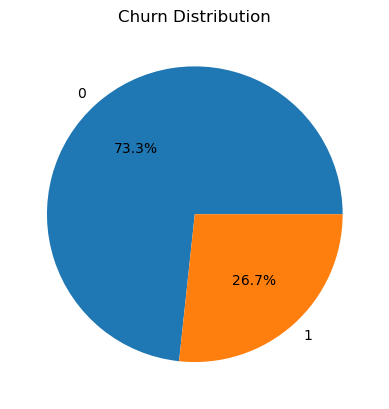

In [29]:
df['Churn'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Churn Distribution")
plt.ylabel("")
plt.show()

###  Churn Rate Analysis

**Result:** ~26.7%

**What it Means:**
Approximately 1 in 4 customers are leaving the service.

**Business Impact:**
- This indicates a relatively high churn rate  
- The company is losing a significant number of customers  

**Insight:**
The company is facing a churn problem and needs to implement effective customer retention strategies.


# Churn By Contract


In [24]:
df.groupby('Contract')['Churn'].mean()

Contract
Month-to-month    0.262815
One year          0.271491
Two year          0.266386
Name: Churn, dtype: float64

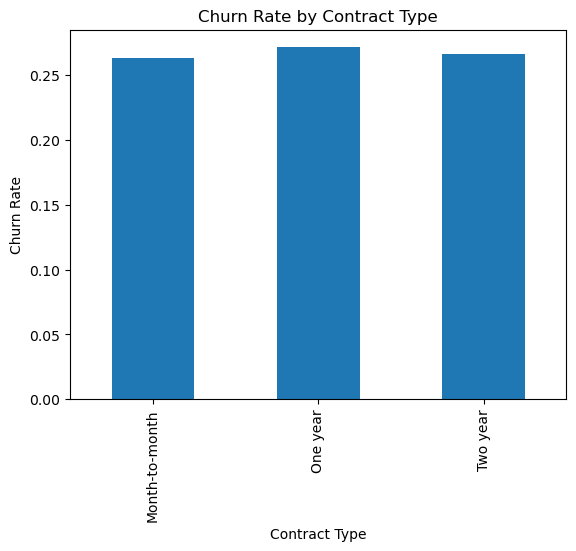

In [27]:
df.groupby('Contract')['Churn'].mean().plot(kind='bar')
plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate")
plt.show()

### Churn By Contract Analysis

**What it Means:**
Month-to-month → highest churn
Long-term (1 year / 2 year) → lower churn

**Business Impact:**
- Customers with short-term commitment are more likely to leave
-Long-term contracts increase loyalty

**Insight:**
Contract type is a major driver of churn, with short-term customers showing significantly higher churn.

# Churn By Gender

In [32]:
df.groupby('Gender')['Churn'].mean()


Gender
Female    0.266693
Male      0.267305
Name: Churn, dtype: float64

### Churn By Gender Analysis

**What it Means:**
Male and Female churn rates are similar

**Business Impact:**
-Gender does not influence customer behavior significantly

**Insight:**
Gender has minimal impact on churn and is not a key factor for targeting retention strategies

# Churn By Senior Citizen

In [13]:
df.groupby('SeniorCitizen')['Churn'].mean()

SeniorCitizen
0    0.265029
1    0.268977
Name: Churn, dtype: float64

### 📊 Churn By Senior Citizen Analysis

**What it Means:**
Slight difference

**Business Impact:**
-Age group may have minor influence
    
**Insight:**
Senior citizen status shows limited impact on churn and is not a strong predictor.

# Churn By Payment Method

In [14]:
df.groupby('PaymentMethod')['Churn'].mean()

PaymentMethod
Bank transfer       0.267943
Credit card         0.270867
Electronic check    0.266693
Mailed check        0.262480
Name: Churn, dtype: float64

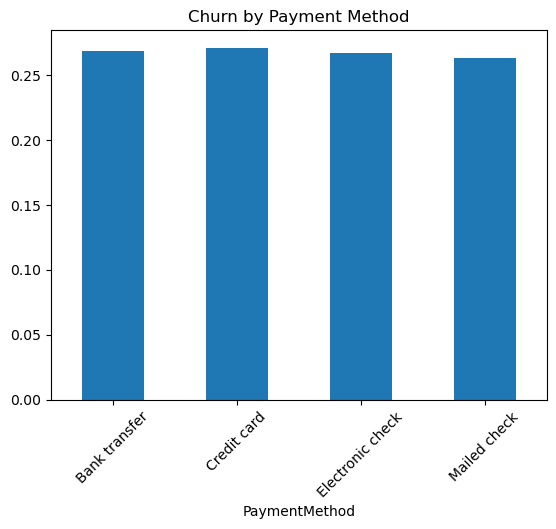

In [30]:
df.groupby('PaymentMethod')['Churn'].mean().plot(kind='bar')
plt.title("Churn by Payment Method")
plt.xticks(rotation=45)
plt.show()

###  Churn By Payment Method Analysis

**What it Means:**
Electronic check users have higher churn
    
**Business Impact:**
 -Payment experience may affect satisfaction
 -Possible issues with digital payments

    
**Insight:**
Payment method significantly impacts churn, with electronic check users showing higher churn rates.


# Churn By Tenure

In [15]:
df.groupby(pd.cut(df['Tenure'], bins=5))['Churn'].mean()

C:\Users\Muskaan\AppData\Local\Temp\ipykernel_6096\1711084192.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(df['Tenure'], bins=5))['Churn'].mean()


Tenure
(0.93, 15.0]    0.267857
(15.0, 29.0]    0.255211
(29.0, 43.0]    0.257322
(43.0, 57.0]    0.281635
(57.0, 71.0]    0.272171
Name: Churn, dtype: float64

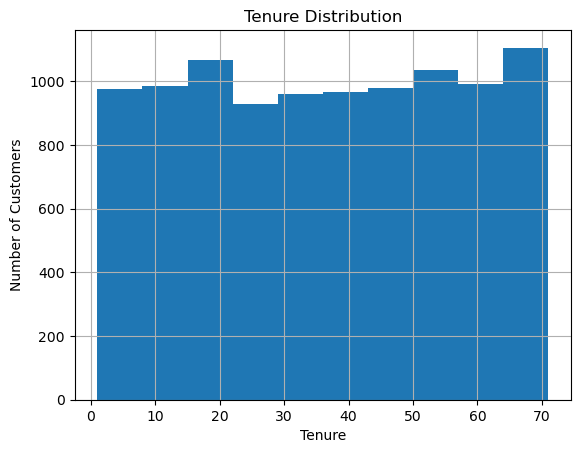

In [31]:
df['Tenure'].hist()
plt.title("Tenure Distribution")
plt.xlabel("Tenure")
plt.ylabel("Number of Customers")
plt.show()

### Churn By Tenure Analysis

**What it Means:**
Churn rate is almost same across tenure groups
    
**Business Impact:**
-Length of customer relationship is not strongly affecting churn
    
**Insight:**
Tenure shows weak correlation with churn, indicating that both new and old customers churn at similar rates.

# Churn vs Monthly Charges

In [16]:
df.groupby(pd.cut(df['MonthlyCharges'], bins=5))['Churn'].mean()

C:\Users\Muskaan\AppData\Local\Temp\ipykernel_6096\2361004570.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(df['MonthlyCharges'], bins=5))['Churn'].mean()


MonthlyCharges
(19.9, 40.0]      0.260981
(40.0, 60.0]      0.271792
(60.0, 80.0]      0.269251
(80.0, 100.0]     0.256836
(100.0, 120.0]    0.276065
Name: Churn, dtype: float64

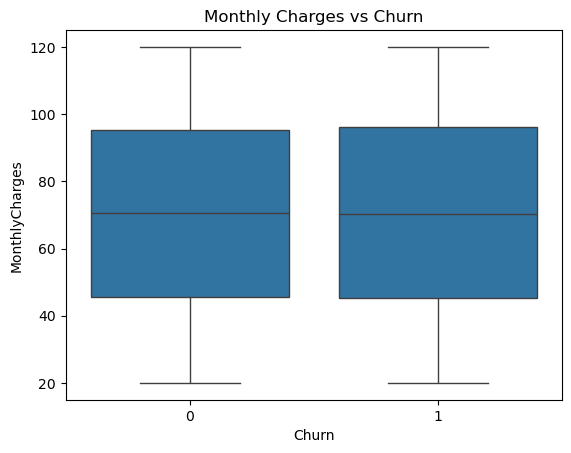

In [28]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

###  Churn vs Monthly Analysis

**What it Means:**
Slight variation but mostly similar

**Business Impact:**
 -Pricing is not a major reason for churn
    
**Insight:**
 Monthly charges have a limited impact on churn, suggesting pricing is not the primary factor driving customer attrition.

# Customer Churn Analysis: Why Are We Losing Customers?




## Problem Statement
A company is experiencing customer churn but does not understand the reasons behind it.

##  Objective
To analyze customer data, identify key drivers of churn, and provide actionable recommendations to reduce customer loss.

# ROOT CAUSE ANALYSIS

##  Root Cause Analysis

Based on the analysis:

- Customers with month-to-month contracts have higher churn due to low commitment
- Customers using electronic payment methods may face usability issues
- Lack of long-term engagement leads to higher customer drop-off

These factors indicate that churn is driven more by customer experience and engagement rather than demographics.

# CHURN PLAYBOOK

##  Churn Playbook (Action Plan)

- If customer has month-to-month contract → Offer discount for yearly plan  
- If payment method is electronic check → Improve payment experience  
- If customer is new → Provide onboarding support  
- If high-value customer → Assign dedicated support  

These actions can help reduce churn and improve customer retention.

# LEADING INDICATORS

## Leading Indicators of Churn

- Contract type (month-to-month)
- Payment method (electronic check)
- Low engagement signals

These indicators can help predict and prevent churn early.

 # FINAL CONCLUSION

## Conclusion

The analysis reveals that customer churn is primarily influenced by contract type and payment method. By addressing these areas and implementing targeted retention strategies, the company can significantly reduce customer loss and improve long-term growth.